## ARCH and GARCH Models

ARCH and GARCH are **time series models** that model **changing volatility over time**, especially useful for financial data like stock returns or exchange rates.

### 1. Why Traditional Models Aren’t Enough

- Traditional models like AR, MA, ARMA, ARIMA focus on **predicting the mean** of a series.  
- They **assume constant variance** over time.  
- Financial data often shows **volatility clustering**: periods of high and low variability.  
- Using ARIMA alone may predict the average trend but **fail to capture extreme volatility**.  
- ARCH/GARCH models address this by modeling **time-varying variance**.

### 2. ARCH (Autoregressive Conditional Heteroskedasticity)

- ARCH models are used to capture **time-varying volatility** in a time series.
- `Volatility` in time series refers to how much and how quickly the values of a time series fluctuate over time. 
- They are particularly useful in financial data, like stocks or exchange rates, where periods of `high` and `low volatility` tend to cluster together.
- Unlike traditional models such as AR, MA, or ARIMA, which **assume constant variance**, ARCH explicitly models variance as changing over time.
- `key concept`: The current volatility (or variance) of a series depends on the squared errors from previous periods. In simple terms:
    - If yesterday there was a big shock (a large deviation from the expected value), today is likely to be more volatile.
    - If yesterday was calm, today is likely calm as well.

Limitations:
- Only considers past shocks, ignoring past variances.
- Can require many lagged terms (large q) to capture long-term volatility, which can be inefficient.

### 3. GARCH (Generalized ARCH)

- Extends ARCH by including **past variances** along with past shocks.  
- **Key Idea:** Current volatility depends on **both past shocks(squared errors) and past volatility**.

Intuition:
- `past shocks`: If there have been large shocks recently, today is likely more volatile.
- `past volatility`: Even if yesterday’s shock wasn’t huge, if the market has been volatile over the past few days, today’s volatility can still be high.

- More flexible and practical for financial data than ARCH alone.  
- **Use Case:** Forecasting volatility in stocks, crypto, commodities.

`GARCH(1,1)` is the most widely used: it considers only the previous period’s squared error and variance but captures volatility well in most financial time series.

### 4. Key Concepts

- ARCH → variance depends on **past squared errors**.  
- GARCH → variance depends on **past squared errors and past variances**.  
- Both are **time series models** used when variance is **not constant**.  
- Useful for modeling **volatility clustering** in financial data.

### 5. Analogy

- ARCH → Looks at the **immediate past** to predict volatility.  
- GARCH → Looks at the **immediate past and past patterns of volatility**.  

**Summary:**  
ARCH/GARCH models are used to forecast **how “wild” or volatile** a time series will be, rather than just predicting the mean.


### Implementation

#### Import Libraries

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from arch import arch_model
# darkgrid style
import seaborn as sns
sns.set_style('darkgrid')

#### Fetch Bitcoin Data

We’ll fetch daily Bitcoin `(BTC-USD)` prices:

In [112]:
# Fetch Bitcoin daily price data from Yahoo Finance
df = yf.download('BTC-USD', start='2020-01-01', end='2025-09-23', interval='1d')

# Display first few rows
print(df.head())

[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open       Volume
Ticker          BTC-USD      BTC-USD      BTC-USD      BTC-USD      BTC-USD
Date                                                                       
2020-01-01  7200.174316  7254.330566  7174.944336  7194.892090  18565664997
2020-01-02  6985.470215  7212.155273  6935.270020  7202.551270  20802083465
2020-01-03  7344.884277  7413.715332  6914.996094  6984.428711  28111481032
2020-01-04  7410.656738  7427.385742  7309.514160  7345.375488  18444271275
2020-01-05  7411.317383  7544.497070  7400.535645  7410.451660  19725074095


In [113]:
# Remove the multi-level column index
df.columns = df.columns.get_level_values(0)

# Check the result
print(df.head())

Price             Close         High          Low         Open       Volume
Date                                                                       
2020-01-01  7200.174316  7254.330566  7174.944336  7194.892090  18565664997
2020-01-02  6985.470215  7212.155273  6935.270020  7202.551270  20802083465
2020-01-03  7344.884277  7413.715332  6914.996094  6984.428711  28111481032
2020-01-04  7410.656738  7427.385742  7309.514160  7345.375488  18444271275
2020-01-05  7411.317383  7544.497070  7400.535645  7410.451660  19725074095


In [114]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2092 entries, 2020-01-01 to 2025-09-22
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2092 non-null   float64
 1   High    2092 non-null   float64
 2   Low     2092 non-null   float64
 3   Open    2092 non-null   float64
 4   Volume  2092 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 98.1 KB


In [111]:
print(df.isnull().sum())

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [66]:
print("Duplicate dates:", df.index.duplicated().sum())

Duplicate dates: 0


### BTC Price Trend

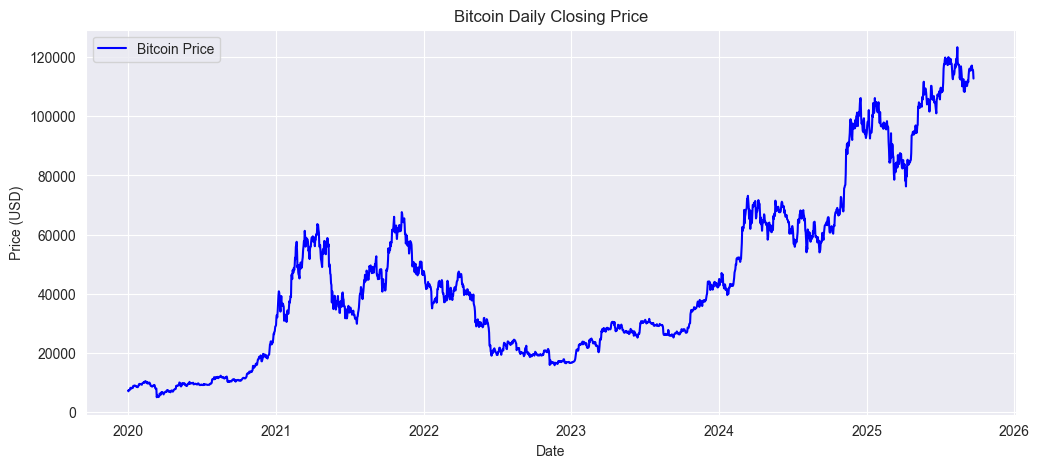

In [67]:
plt.figure(figsize=(12,5))
plt.plot(df['Close'], label='Bitcoin Price', color='blue')
plt.title('Bitcoin Daily Closing Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

### Decompose the time series

Because the data is daily, let's initially investigate a weekly seasonal period of 7.

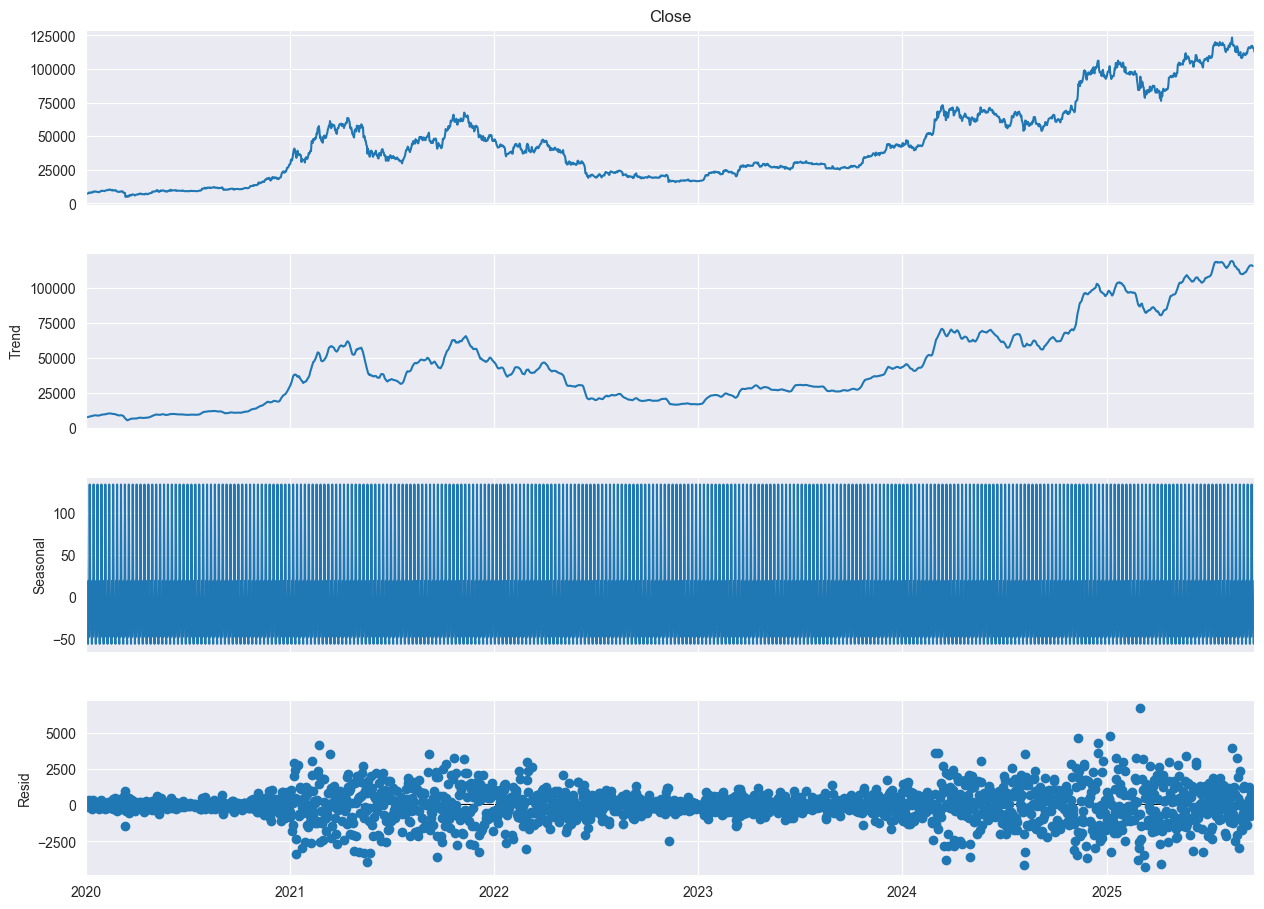

In [26]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(
    df["Close"],
    model="additive",
    period=7
)

fig = decomposition.plot()

fig.set_size_inches(14, 10)

plt.show()

### Check stationarity

In [28]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df["Close"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: -0.3064316514605628
p-value: 0.9245884654830023
Critical Value (1%): -3.4335008163402327
Critical Value (5%): -2.8629318897058345
Critical Value (10%): -2.5675109777577276


C:\Users\user\AppData\Local\Temp\ipykernel_21216\1520202682.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(df["Close"])


p-value = 0.9246 > 0.05

- The Bitcoin Close price series is non-stationary.

### Let's try first-order differencing

In [115]:
df["Close_diff"] = df["Close"].diff()

df["Close_diff"].head()

Date
2020-01-01           NaN
2020-01-02   -214.704102
2020-01-03    359.414062
2020-01-04     65.772461
2020-01-05      0.660645
Name: Close_diff, dtype: float64

In [116]:
close_diff = df["Close_diff"].dropna()

### Now run the ADF test again:

In [31]:

adf_result = adfuller(close_diff)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

for key, value in adf_result[4].items():
    print(f"Critical Value ({key}):", value)

ADF Statistic: -11.788790342463463
p-value: 9.94029268825409e-22
Critical Value (1%): -3.4335008163402327
Critical Value (5%): -2.8629318897058345
Critical Value (10%): -2.5675109777577276


C:\Users\user\AppData\Local\Temp\ipykernel_21216\2622997466.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_result = adfuller(close_diff)


The first-differenced Bitcoin Close series is stationary.

### ACF and PACF

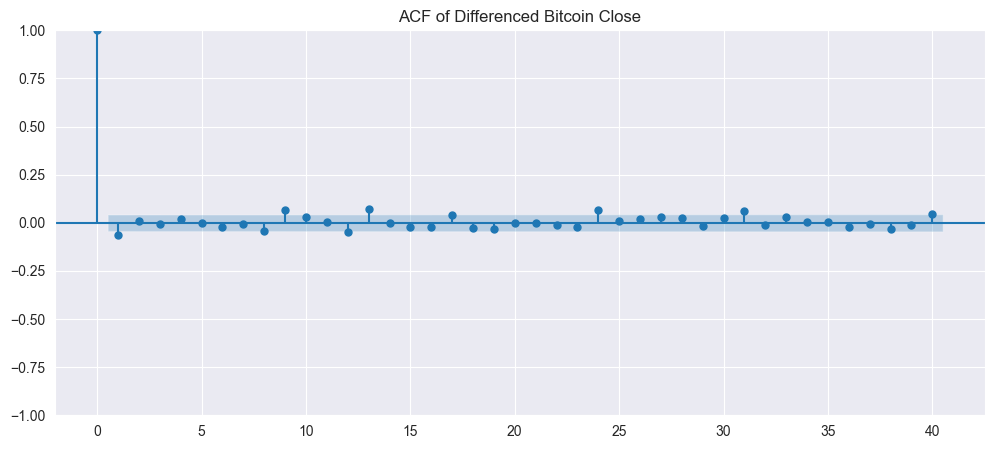

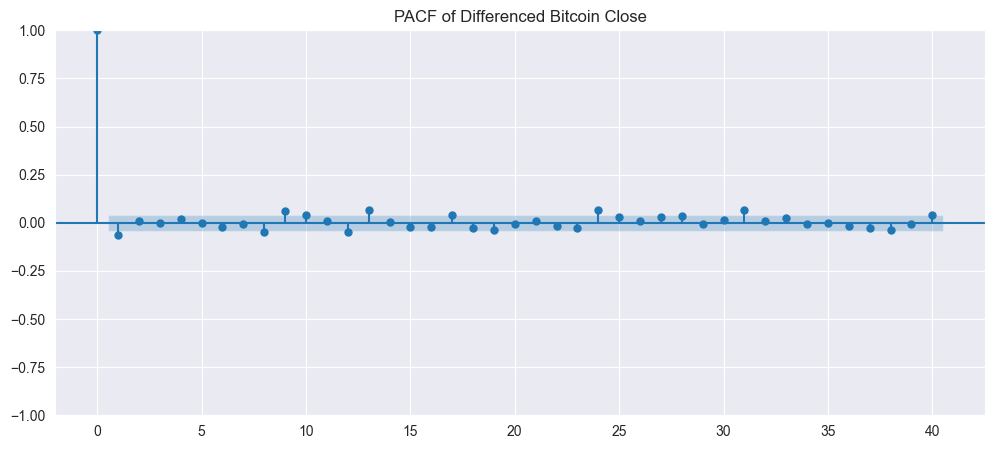

In [32]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(close_diff, lags=40, ax=ax)
plt.title("ACF of Differenced Bitcoin Close")
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
plot_pacf(close_diff, lags=40, method="ywm", ax=ax)
plt.title("PACF of Differenced Bitcoin Close")
plt.show()

### split the data chronologically

In [117]:
train_size = int(len(df) * 0.8)

train = df["Close"].iloc[:train_size]
test = df["Close"].iloc[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 1673
Test size: 419


### Visualize train test split

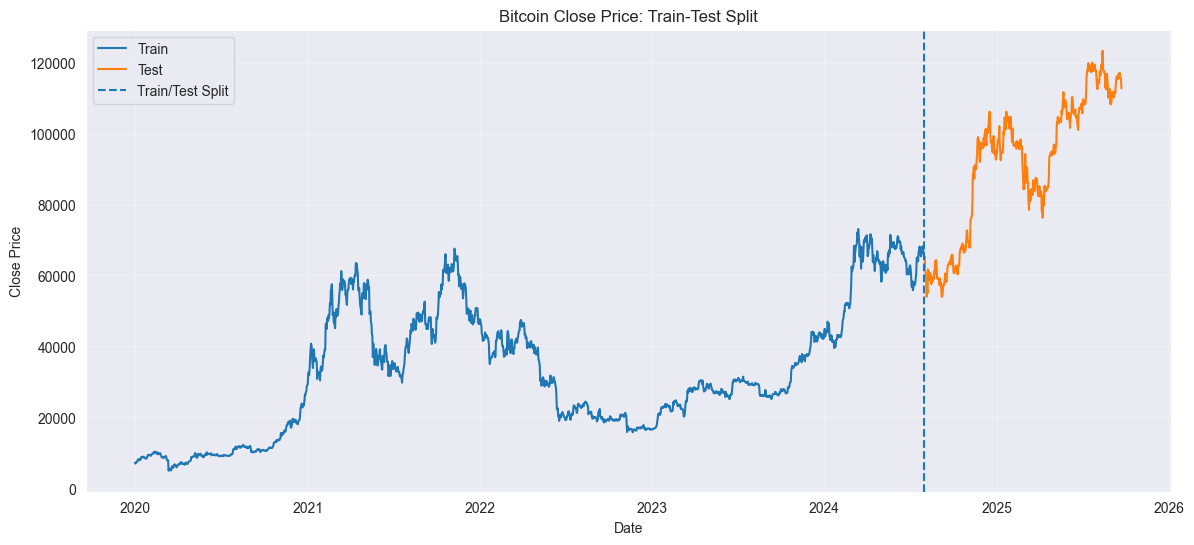

In [34]:
plt.figure(figsize=(14, 6))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")

plt.axvline(
    x=test.index[0],
    linestyle="--",
    label="Train/Test Split"
)

plt.title("Bitcoin Close Price: Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Using Auto Arima

In [35]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    d=1,
    seasonal=False,
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    information_criterion="aic"
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=28548.449, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=28545.483, Time=0.07 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=28545.617, Time=0.18 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=28547.819, Time=0.04 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=28547.313, Time=0.14 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=28547.409, Time=0.18 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=28548.999, Time=0.78 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=28545.021, Time=0.06 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=28546.816, Time=0.08 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=28546.919, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=28545.156, Time=0.09 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=28546.724, Time=0.51 sec

Best model:  ARIMA(1,1,0)(0,0,0)[0]          
Total fit time: 2.301 seconds
                               SARIMAX Results                              

ARIMA(1,1,0)

where:

- p = 1: one autoregressive term
- d = 1: first-order differencing
- q = 0: no moving-average term

### Fit ARIMA Model

In [118]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(1,1,0) on the training data
model = ARIMA(train, order=(1, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

c:\Users\user\Desktop\data-science-class\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\user\Desktop\data-science-class\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\user\Desktop\data-science-class\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 1673
Model:                 ARIMA(1, 1, 0)   Log Likelihood              -14270.511
Date:                Wed, 23 Sep 2026   AIC                          28545.021
Time:                        10:25:42   BIC                          28555.865
Sample:                    01-01-2020   HQIC                         28549.039
                         - 07-30-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0533      0.017     -3.075      0.002      -0.087      -0.019
sigma2      1.518e+06   2.72e+04     55.856      0.000    1.46e+06    1.57e+06
Ljung-Box (L1) (Q):                   0.00   Jarque-

### check the residuals

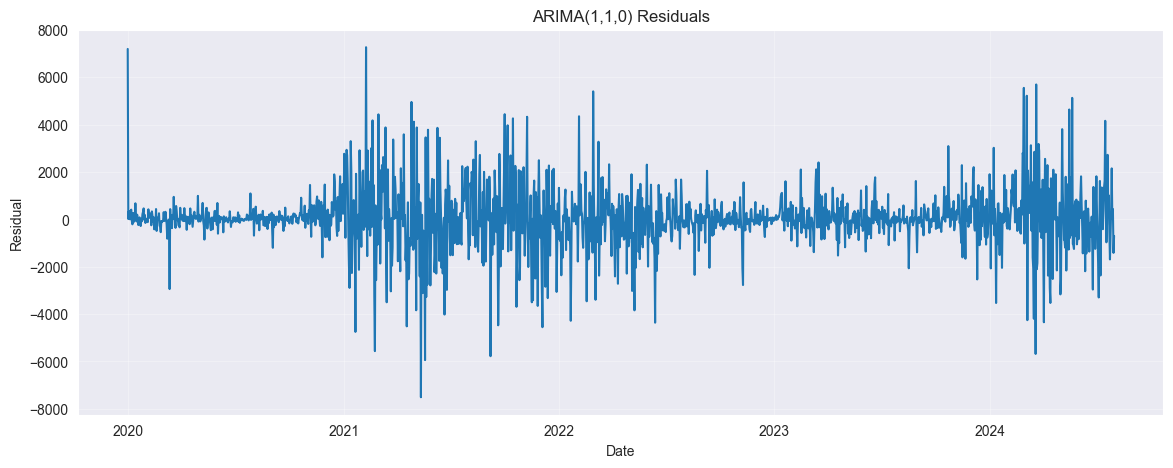

In [37]:
residuals = model_fit.resid

plt.figure(figsize=(14, 5))
plt.plot(residuals)
plt.title("ARIMA(1,1,0) Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)
plt.show()

### Ljung-Box test to check whether the residuals still contain autocorrelation.

In [38]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    model_fit.resid,
    lags=[10, 20],
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
10  14.251583   0.161822
20  28.486498   0.098374


Both p-values are greater than 0.05:

Therefore, we fail to reject H₀ at both lag 10 and lag 20.

There is no statistically significant evidence of remaining autocorrelation in the ARIMA(1,1,0) residuals at lags 10 and 20.

### Forecast the test set

In [119]:
forecast = model_fit.forecast(steps=len(test))

forecast.index = test.index

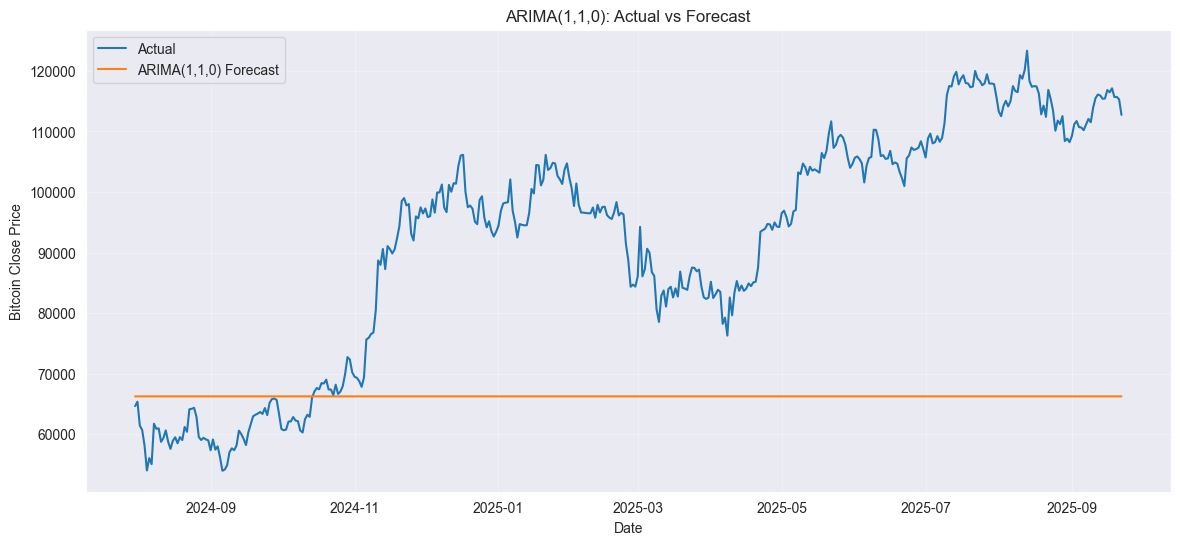

In [120]:
plt.figure(figsize=(14, 6))

plt.plot(test.index, test, label="Actual")
plt.plot(forecast.index, forecast, label="ARIMA(1,1,0) Forecast")

plt.title("ARIMA(1,1,0): Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Bitcoin Close Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [121]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

arima_mae = mean_absolute_error(test, forecast)
arima_rmse = np.sqrt(mean_squared_error(test, forecast))

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 27550.712926696287
ARIMA RMSE: 31863.306419799046


### Fit a SARIMA model

In [122]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1, 1, 0),
    seasonal_order=(1, 0, 0, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

c:\Users\user\Desktop\data-science-class\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\user\Desktop\data-science-class\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             Close   No. Observations:                 1673
Model:             SARIMAX(1, 1, 0)x(1, 0, 0, 7)   Log Likelihood              -14205.895
Date:                           Wed, 23 Sep 2026   AIC                          28417.789
Time:                                   10:26:21   BIC                          28434.040
Sample:                               01-01-2020   HQIC                         28423.812
                                    - 07-30-2024                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0541      0.017     -3.124      0.002      -0.088      -0.020
ar.S.L7       -0.0146      0.016     -0.895

### SARIMA residuals

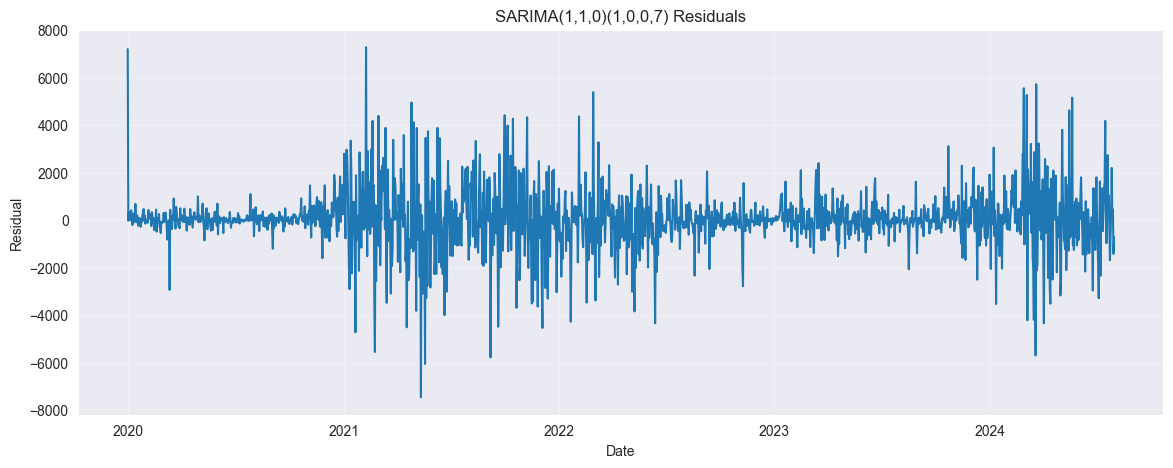

In [123]:
sarima_residuals = sarima_fit.resid

plt.figure(figsize=(14, 5))
plt.plot(sarima_residuals)
plt.title("SARIMA(1,1,0)(1,0,0,7) Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)
plt.show()

#### Ljung-Box test:

In [124]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box_sarima = acorr_ljungbox(
    sarima_residuals,
    lags=[10, 20],
    return_df=True
)

print(ljung_box_sarima)

      lb_stat  lb_pvalue
10  14.142821   0.166576
20  28.546235   0.097086


#### Forecast the test set

In [125]:
sarima_forecast = sarima_fit.forecast(steps=len(test))

sarima_forecast.index = test.index

#### Visualize the forecast

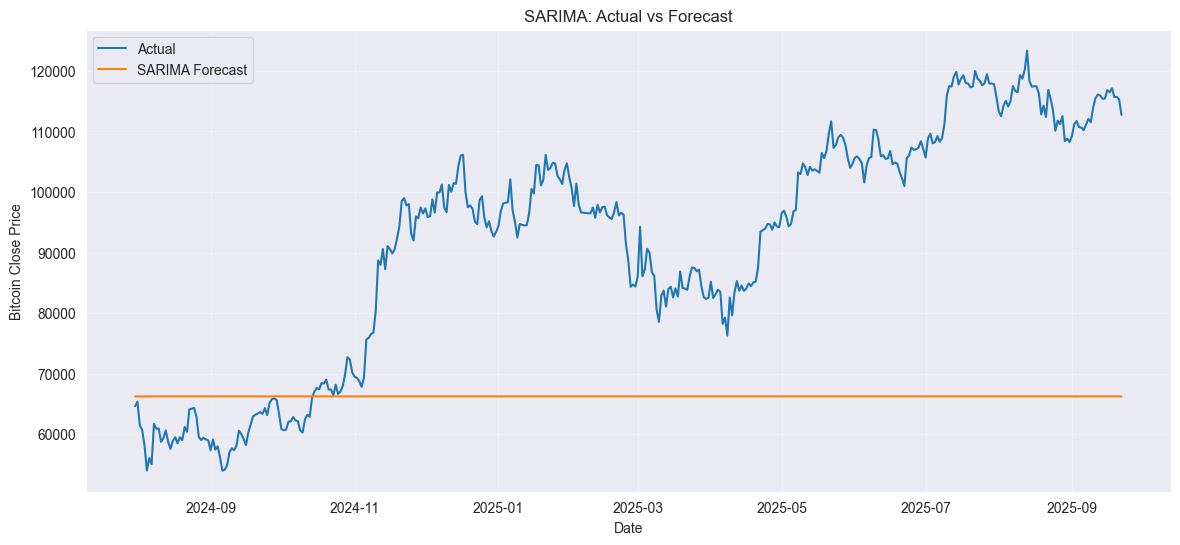

In [126]:
plt.figure(figsize=(14, 6))

plt.plot(test.index, test, label="Actual")
plt.plot(
    sarima_forecast.index,
    sarima_forecast,
    label="SARIMA Forecast"
)

plt.title("SARIMA: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Bitcoin Close Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

#### Evaluation

In [127]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(
    mean_squared_error(test, sarima_forecast)
)

print("SARIMA MAE:", sarima_mae)
print("SARIMA RMSE:", sarima_rmse)

SARIMA MAE: 27552.285131604585
SARIMA RMSE: 31865.43425307049


In [48]:
from pmdarima import auto_arima

auto_sarima = auto_arima(
    train,
    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    d=1,
    seasonal=True,
    m=7,
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    information_criterion="aic"
)

print(auto_sarima.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=28548.449, Time=0.17 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=28547.075, Time=0.86 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=28547.253, Time=0.63 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=28547.819, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[7] intercept   : AIC=28545.483, Time=0.09 sec
 ARIMA(1,1,0)(0,0,1)[7] intercept   : AIC=28547.108, Time=0.35 sec
 ARIMA(1,1,0)(1,0,1)[7] intercept   : AIC=28542.143, Time=2.53 sec
 ARIMA(1,1,0)(2,0,1)[7] intercept   : AIC=28547.478, Time=2.45 sec
 ARIMA(1,1,0)(1,0,2)[7] intercept   : AIC=28547.609, Time=2.13 sec
 ARIMA(1,1,0)(0,0,2)[7] intercept   : AIC=28546.200, Time=0.57 sec
 ARIMA(1,1,0)(2,0,0)[7] intercept   : AIC=28545.848, Time=0.60 sec
 ARIMA(1,1,0)(2,0,2)[7] intercept   : AIC=28543.869, Time=3.71 sec
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=28545.615, Time=1.16 sec
 ARIMA(2,1,0)(1,0,1)[7] intercept   : AIC=28543.978, Time=1.72 sec
 ARIMA(1,1,1)(1,0,1

### GARCH models the conditional variance/volatility.
For GARCH, we generally work with returns, not the raw Bitcoin price.

#### 1. Compute Daily Returns

ARCH/GARCH models work on returns, not raw prices:

In [128]:
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

returns = df["log_return"].dropna()

In [129]:
returns.head()

Date
2020-01-02   -0.030273
2020-01-03    0.050172
2020-01-04    0.008915
2020-01-05    0.000089
2020-01-06    0.047161
Name: log_return, dtype: float64

### Plot the returns

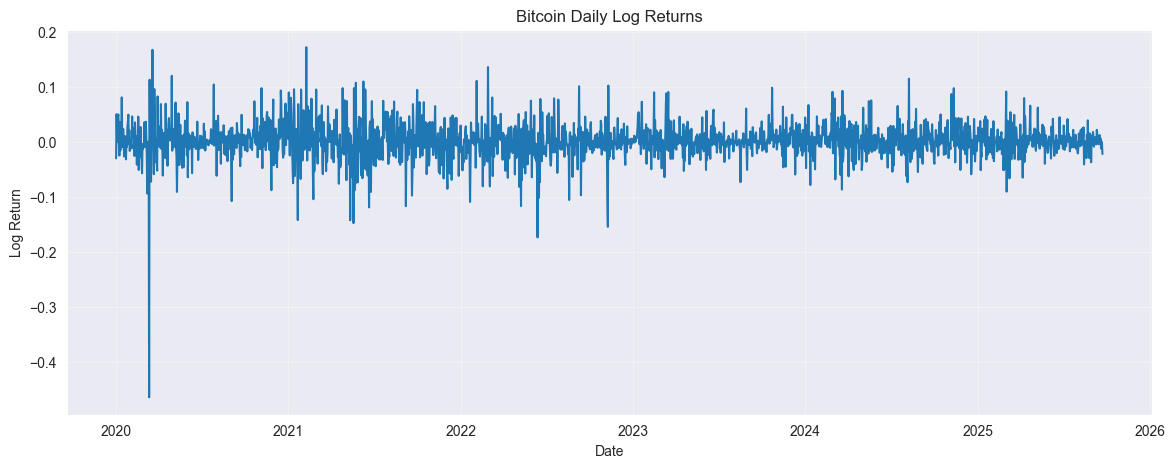

In [130]:

plt.figure(figsize=(14, 5))
plt.plot(returns)
plt.title("Bitcoin Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True, alpha=0.3)
plt.show()

- Daily return measures how much Bitcoin’s closing price changed (in %) from one day to the next.
- Returns are typically `stationary in the mean`, which ARCH/GARCH require.

### Train-Test split

In [131]:
train_size = int(len(returns) * 0.8)

train_returns = returns.iloc[:train_size]
test_returns = returns.iloc[train_size:]

### Fit a basic GARCH(1,1)

We'll start simple:

The model is:

$$ \sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta\sigma_{t-1}^2 $$

where:

- \(\sigma_t^2\) = current conditional variance
- \(\omega\) = baseline variance
- \(\alpha\) = effect of recent shocks
- \(\beta\) = persistence of previous volatility

In [132]:
from arch import arch_model

garch_model = arch_model(
    train_returns,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1
)

garch_fit = garch_model.fit(disp="off")

print(garch_fit.summary())

c:\Users\user\Desktop\data-science-class\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001198. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


                     Constant Mean - GARCH Model Results                      
Dep. Variable:             log_return   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:                3330.32
Distribution:                  Normal   AIC:                          -6652.64
Method:            Maximum Likelihood   BIC:                          -6630.95
                                        No. Observations:                 1672
Date:                Wed, Sep 23 2026   Df Residuals:                     1671
Time:                        10:28:35   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu         2.1870e-03  8.368e-04      2.614  8.961e-03 [5.

### GARCH(1,1) Results

* **Omega = 0.00010985 (p = 0.158):** Not statistically significant at the 5% level, suggesting limited evidence for a significant constant component in the conditional variance.

* **Alpha = 0.1068 (p = 0.0023):** Statistically significant, indicating that recent return shocks have a significant effect on current volatility.

* **Beta = 0.8061 (p < 0.001):** Highly statistically significant and relatively high, indicating strong volatility persistence. When volatility increases, it tends to remain elevated for some time before returning toward its long-run level.

* **Alpha + Beta = 0.9129:** Indicates a high degree of volatility persistence, meaning shocks to Bitcoin's volatility tend to decay gradually rather than disappearing quickly.


#### Generate GARCH volatility forecasts for the test set

In [133]:
forecast = garch_fit.forecast(
    horizon=len(test_returns),
    reindex=False
)

predicted_variance = forecast.variance.iloc[-1].values
predicted_volatility = np.sqrt(predicted_variance)

predicted_volatility = pd.Series(
    predicted_volatility,
    index=test_returns.index
)

#### Get actual volatility

In [134]:
actual_volatility = test_returns.abs()

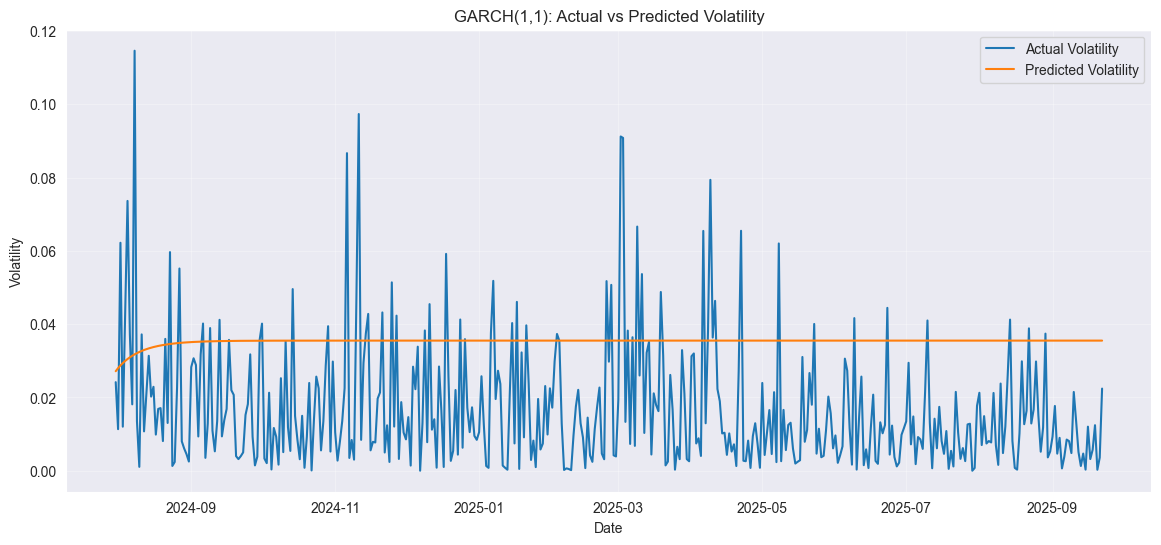

In [135]:
plt.figure(figsize=(14, 6))

plt.plot(
    actual_volatility.index,
    actual_volatility,
    label="Actual Volatility"
)

plt.plot(
    predicted_volatility.index,
    predicted_volatility,
    label="Predicted Volatility"
)

plt.title("GARCH(1,1): Actual vs Predicted Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Prophet Model

we mainly need the Date and Close columns. Prophet expects them to be named `ds` and `y`.

In [136]:
df.head()

Price,Close,High,Low,Open,Volume,Close_diff,log_return
Date,,,,,,,
2020-01-01,7200.174316,7254.330566,7174.944336,7194.892090,18565664997,NaN,NaN
2020-01-02,6985.470215,7212.155273,6935.270020,7202.551270,20802083465,-214.704102,-0.030273
2020-01-03,7344.884277,7413.715332,6914.996094,6984.428711,28111481032,359.414062,0.050172
2020-01-04,7410.656738,7427.385742,7309.514160,7345.375488,18444271275,65.772461,0.008915
2020-01-05,7411.317383,7544.497070,7400.535645,7410.451660,19725074095,0.660645,0.000089


In [75]:
print(df.columns)
print(type(df.columns))

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')
<class 'pandas.Index'>


In [76]:
from prophet import Prophet

# Prepare data for Prophet
prophet_df = df[["Close"]].reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2020-01-01,7200.174316
1,2020-01-02,6985.470215
2,2020-01-03,7344.884277
3,2020-01-04,7410.656738
4,2020-01-05,7411.317383


In [77]:
print(prophet_df.dtypes)

ds    datetime64[s]
y           float64
dtype: object


### Train-test split

In [80]:
train_size = int(len(prophet_df) * 0.8)

train = prophet_df.iloc[:train_size]
test = prophet_df.iloc[train_size:]

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Training period:", train["ds"].min(), "to", train["ds"].max())
print("Testing period:", test["ds"].min(), "to", test["ds"].max())

Training observations: 1673
Testing observations: 419
Training period: 2020-01-01 00:00:00 to 2024-07-30 00:00:00
Testing period: 2024-07-31 00:00:00 to 2025-09-22 00:00:00


### Fit Prophet

In [81]:

model = Prophet()

model.fit(train)

08:09:58 - cmdstanpy - INFO - Chain [1] start processing
08:10:01 - cmdstanpy - INFO - Chain [1] done processing


### Generate predictions for the test period

Since we only want to predict the dates in our test set:

In [82]:
future = test[["ds"]].copy()

forecast = model.predict(future)

In [83]:
# Check the predictions:
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].head()

,ds,yhat,yhat_lower,yhat_upper
0,2024-07-31,68273.878942,63589.248670,73320.798972
1,2024-08-01,68385.838952,63233.119711,73513.010878
2,2024-08-02,68610.367061,63509.380702,73528.974528
3,2024-08-03,68833.581906,64002.953382,73849.094520
4,2024-08-04,69087.168524,64148.120872,74088.338980


- yhat = predicted Bitcoin closing price
- yhat_lower = lower uncertainty bound
- yhat_upper = upper uncertainty bound

### Plot actual vs predicted

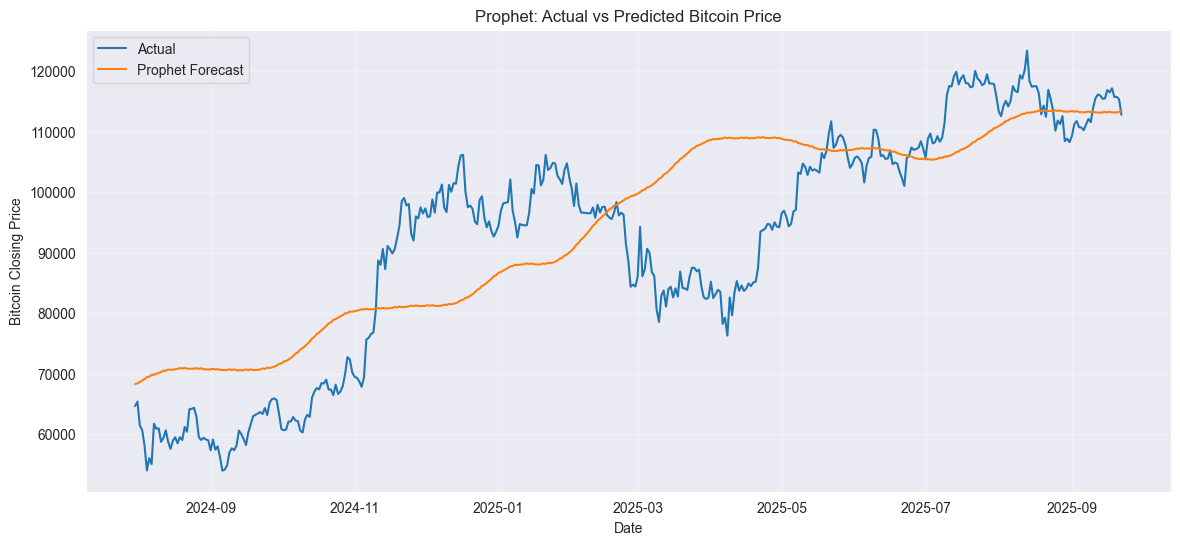

In [84]:
plt.figure(figsize=(14, 6))

plt.plot(
    test["ds"],
    test["y"],
    label="Actual"
)

plt.plot(
    forecast["ds"],
    forecast["yhat"],
    label="Prophet Forecast"
)

plt.title("Prophet: Actual vs Predicted Bitcoin Price")
plt.xlabel("Date")
plt.ylabel("Bitcoin Closing Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Evaluate Prophet

In [85]:
actual = test["y"].values
predicted = forecast["yhat"].values

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print("Prophet MAE:", mae)
print("Prophet RMSE:", rmse)

Prophet MAE: 9942.238862085118
Prophet RMSE: 12122.007677472637


### RNN

RNN learns patterns from sequences of previous prices, rather than explicitly modelling autocorrelation like ARIMA.

RNN reads a sequence one time step at a time while carrying a memory of what it has seen so far.

Suppose we have:

Day 1   Day 2   Day 3   Day 4   ...   Day 30   Day 31
7200    6985    7344    7410    ...   8000     8200

Our goal is:

Use the previous 30 days to predict Day 31.

But the RNN doesn't see all 30 days as one big number

The RNN processes the sequence step by step:

Day 1 → Day 2 → Day 3 → ... → Day 30

At each step, it receives:

current price + its previous memory

The `hidden state` is what gives the RNN its memory.

In [88]:
# Use Close price
data = df[["Close"]].copy()

# Make sure it's sorted by date
data = data.sort_index()

data.head()

Price,Close
Date,
2020-01-01,7200.174316
2020-01-02,6985.470215
2020-01-03,7344.884277
2020-01-04,7410.656738
2020-01-05,7411.317383


#### Splitting

In [89]:
train_size = int(len(data) * 0.8)

train = data.iloc[:train_size]
test = data.iloc[train_size:]

print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 1673
Testing observations: 419


#### Scale the data

Neural networks generally train better when the values are on a smaller scale.

We'll use MinMaxScaler:

both MinMaxScaler and StandardScaler can work. Min-Max scaling is commonly used in RNN/LSTM forecasting because:

- It puts the input into a predictable bounded range.
- It works well with tanh/sigmoid-based recurrent networks.

In [90]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(train)
test_scaled = scaler.transform(test)

#### Create sequences

Suppose you have 400 training observations and lookback = 30.

#### The RNN does not receive all 400 at once

Instead, the create_sequences() function creates many overlapping training examples:

An RNN needs sequences such as:

- Observation 1–30   → Predict 31
- Observation 2–31   → Predict 32
- Observation 3–32   → Predict 33
...
Observation 370–399 → Predict 400

Let's use a 30-day lookback window.

In [91]:
def create_sequences(data, lookback=30):
    X = []
    y = []

    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])

    return np.array(X), np.array(y)

X will store the inputs given to the model.
y stores the answers that we want the model to learn to predict.

`X.append(data[i-lookback:i])`

Take the previous 30 observations and put them into X."

For the training data:

In [92]:
lookback = 30

X_train, y_train = create_sequences(
    train_scaled,
    lookback
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (1643, 30, 1)
y_train shape: (1643, 1)


- 1643 training sequences
- 30 previous time steps per sequence
- 1 feature at each time step

#### Create the test sequences

There's one important detail here.

We need the last 30 training observations to provide historical context for the first test prediction.

In [93]:
test_input = np.concatenate([
    train_scaled[-lookback:],
    test_scaled
])

X_test, y_test = create_sequences(
    test_input,
    lookback
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (419, 30, 1)
y_test shape: (419, 1)


So we're predicting the entire test period without using the actual future test prices as inputs.

### Build the RNN

Now we can create a simple vanilla RNN.

Here:

- SimpleRNN(50) = 50 recurrent units (neurons)
- 30 = 30 days of historical information
- 1 = Close price as the input feature
- Dense(1) = one predicted closing price
- mse = Mean Squared Error, appropriate for a regression problem

This is different from the binary_crossentropy you asked about earlier. Bitcoin price prediction is regression, not binary classification, so we use a regression loss such as MSE.

input_shape=(lookback, 1)

This tells the RNN what one training sequence looks like.

In [94]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

model = Sequential([
    SimpleRNN(50, activation="tanh", input_shape=(lookback, 1)),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

c:\Users\user\Desktop\data-science-class\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

### Train the RNN

1,643 × 90% ≈ 1,479 training sequences
1,643 × 10% ≈   164 validation sequences

The 1,479 training sequences are then processed in batches of 32:

- Batch 1    32 sequences
- Batch 2    32 sequences
- Batch 3    32 sequences

- Batch 46   remaining sequences

So the model processes 32 sequences at a time.

$$ \frac{1479}{32} = 46.22 $$

You can't have 0.22 of a batch, so Keras needs 47 batches, not 46.

In [95]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - loss: 0.0062 - val_loss: 0.0016
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0011 - val_loss: 0.0071
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0013 - val_loss: 0.0026
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0028 - val_loss: 0.0049
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 8.1370e-04 - val_loss: 0.0027
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 7.5289e-04 - val_loss: 0.0022
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 7.2307e-04 - val_loss: 0.0019
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 6.6394e-04 - val_loss: 0.0018
Epoch 9/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.4158e-04 - val_loss: 0.0017
Epoch 10/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.1419e-04 - val_loss: 0.0017
Epoch 11/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 5.9297e-04 - val_loss: 0.0016
Epoch 12/30
47/47 ━━━━━━━━━━━━━━━━

### Plot training and validation loss

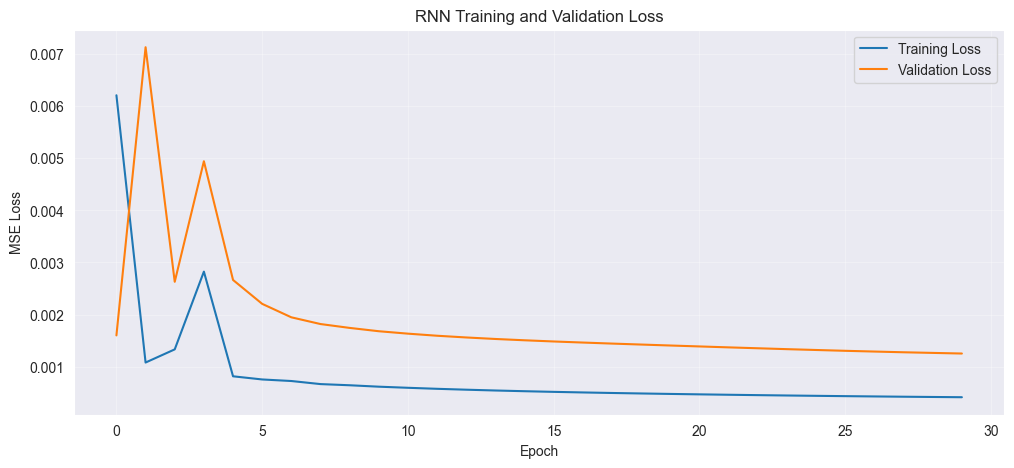

In [96]:
plt.figure(figsize=(12, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("RNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

#### Generate predictions

In [97]:
predictions_scaled = model.predict(X_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


The predictions are still scaled, so we need to convert them back to the original Bitcoin price scale.

In [98]:
predictions = scaler.inverse_transform(predictions_scaled)
actual = scaler.inverse_transform(y_test)

### Evaluate the RNN

In [99]:
rnn_mae = mean_absolute_error(actual, predictions)
rnn_rmse = np.sqrt(mean_squared_error(actual, predictions))

print("RNN MAE:", rnn_mae)
print("RNN RMSE:", rnn_rmse)

RNN MAE: 5451.654282890811
RNN RMSE: 6346.285495655659


### Plot actual vs predicted

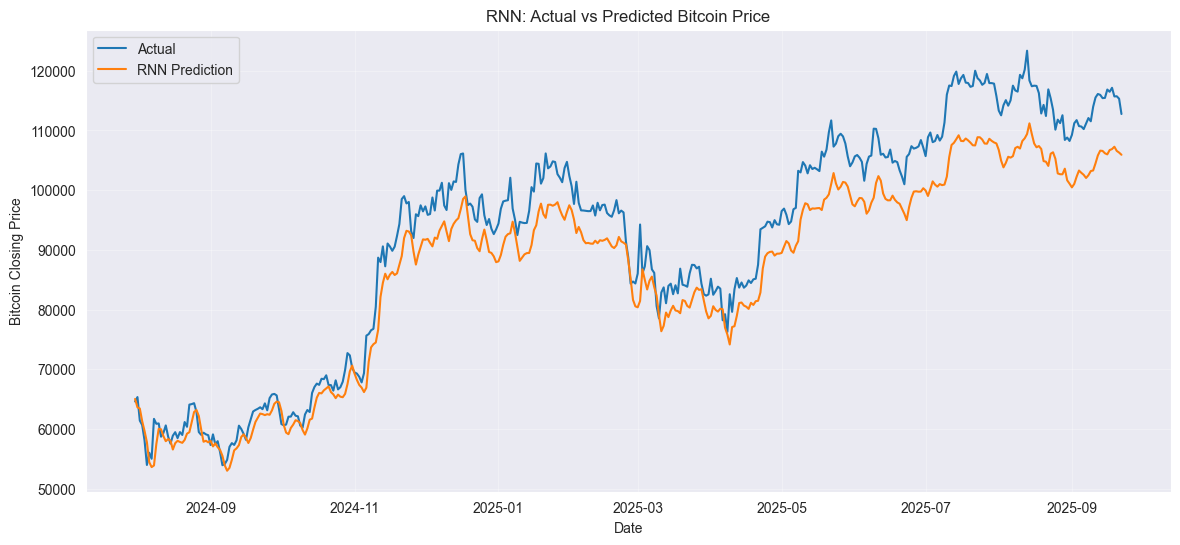

In [100]:
test_dates = test.index

plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    actual.flatten(),
    label="Actual"
)

plt.plot(
    test_dates,
    predictions.flatten(),
    label="RNN Prediction"
)

plt.title("RNN: Actual vs Predicted Bitcoin Price")
plt.xlabel("Date")
plt.ylabel("Bitcoin Closing Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### LSTM

We'll reuse the existing X_train, y_train, X_test, and y_test.

In [101]:
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential([
    LSTM(50, activation="tanh", input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

c:\Users\user\Desktop\data-science-class\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [102]:
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    shuffle=False
)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - loss: 0.0049 - val_loss: 0.0233
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0035 - val_loss: 0.0018
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0019 - val_loss: 0.0020
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0014 - val_loss: 0.0017
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0012 - val_loss: 0.0016
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 9/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0011 - val_loss: 0.0016
Epoch 10/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0011 - val_loss: 0.0015
Epoch 11/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0010 - val_loss: 0.0015
Epoch 12/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 9

### Plot training and validation loss

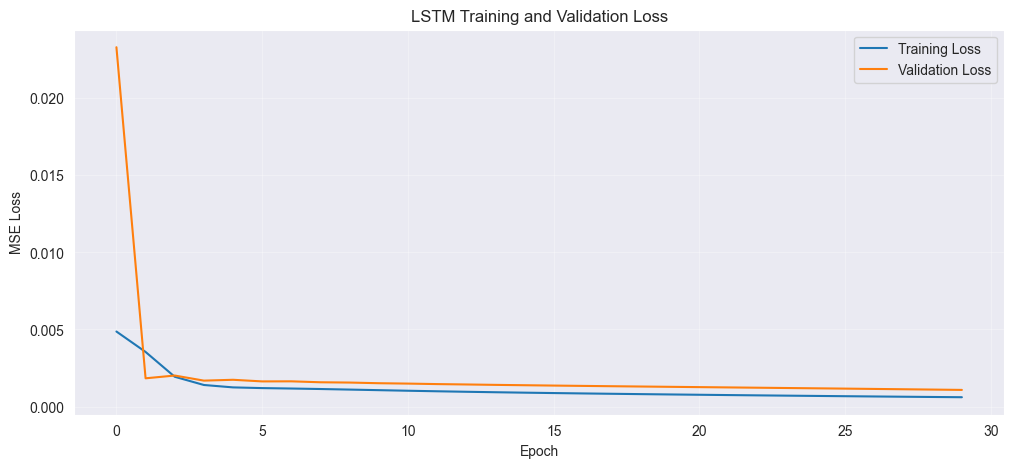

In [103]:
plt.figure(figsize=(12, 5))

plt.plot(lstm_history.history["loss"], label="Training Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

### Generate predictions

In [104]:
lstm_predictions_scaled = lstm_model.predict(X_test)

lstm_predictions = scaler.inverse_transform(lstm_predictions_scaled)
lstm_actual = scaler.inverse_transform(y_test)

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


### Evaluate

In [105]:
lstm_mae = mean_absolute_error(
    lstm_actual,
    lstm_predictions
)

lstm_rmse = np.sqrt(
    mean_squared_error(
        lstm_actual,
        lstm_predictions
    )
)

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)

LSTM MAE: 2101.165349045346
LSTM RMSE: 2736.12870094562


### Actual vs predicted

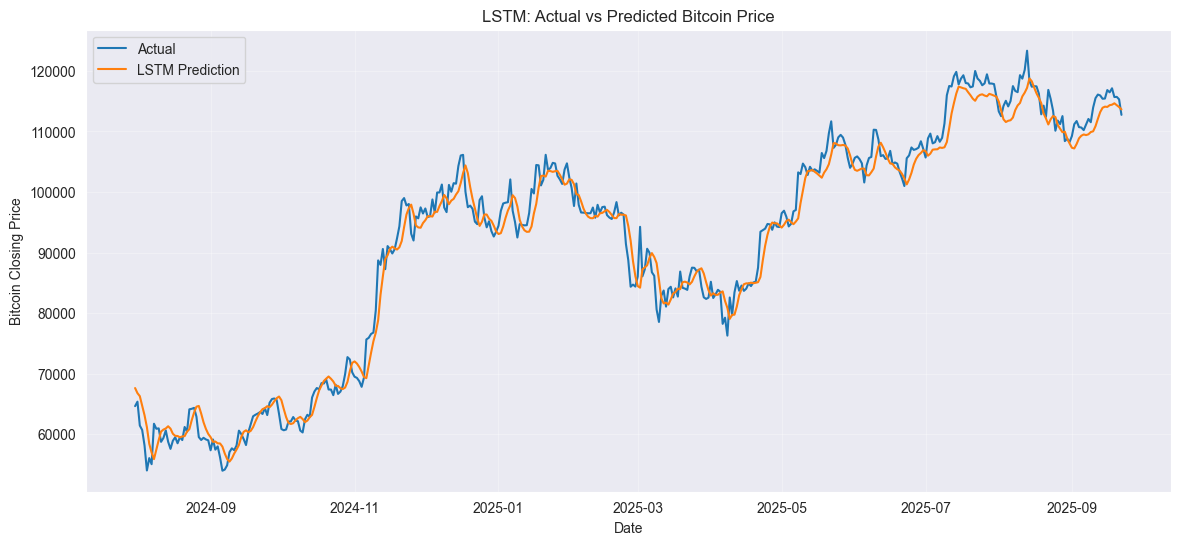

In [106]:
plt.figure(figsize=(14, 6))

plt.plot(
    test.index,
    lstm_actual.flatten(),
    label="Actual"
)

plt.plot(
    test.index,
    lstm_predictions.flatten(),
    label="LSTM Prediction"
)

plt.title("LSTM: Actual vs Predicted Bitcoin Price")
plt.xlabel("Date")
plt.ylabel("Bitcoin Closing Price")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()